In [1]:
!export JAX_PLATFORMS=cpu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surmof_cavity import eps_cav, eps_ag
import matplotlib as mpl

In [3]:
%config InlineBackend.figure_format='retina'

In [4]:
to_THz = 300/2/np.pi
freq_range = (200, 800)
mm = 0.1/2.54

In [5]:
osc=1
damping=1
# fnames = [
#     "out/subdivide_smat_1pole.pkl",
#     "out/small_d_smat_1pole.pkl"
# ]
# npoles = 1
# name = "large_sweep_1pole"
# fig_width = 90*mm

# fnames = [
#     "out/subdivide_smat.pkl",
#     "out/small_d_smat_3pole.pkl",
#     #"fine_3pole.pkl"
# ]
# npoles = 3
# name = "large_sweep_3pole"
# fig_width = 190*mm

npoles = 3
fnames = [
    f"fine_{npoles}pole_{osc}osc_{damping}damping.pkl",
]
name = f"{npoles}pole_{osc}osc_{damping}damping"
fig_width = 90*mm

poles = []
residues = []
thickness = []

for fname in fnames:
    with open(fname, "rb") as file:
        results = pickle.load(file)

    poles += results['poles']
    residues += results['residues']
    thickness += list(results['thickness'])

sorter = np.argsort(thickness)
poles    = [poles[i]    for i in sorter]
residues = [residues[i] for i in sorter]
thickness = np.array(thickness)[sorter]


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [6]:
f0 = np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])
omega0 = f0*2*np.pi
gamma = np.array([6.2, 6.0, 5.3]) * damping *2*np.pi

material_poles = np.sqrt(omega0**2-1/4*gamma**2) - 1j*gamma/2 
material_poles = material_poles[-npoles:]

f0 = f0[::-1]
gamma = gamma[::-1]
material_poles = material_poles[::-1]

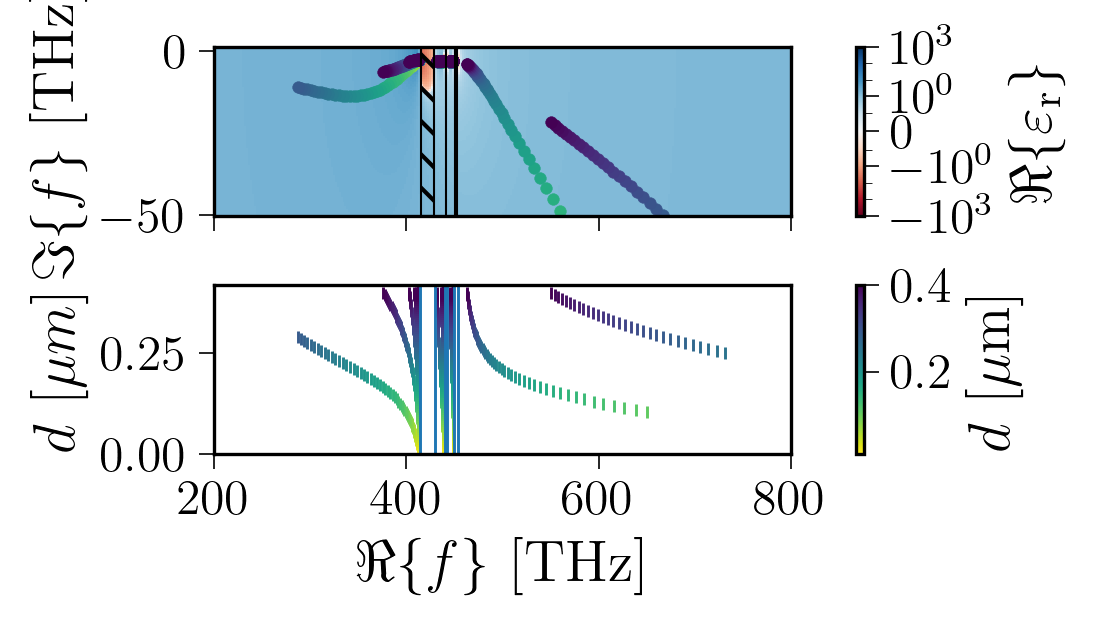

In [7]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(90*mm,50*mm), constrained_layout=True)
plt.sca(axs[0])
w_r = np.linspace(200, 800, 300)
#w_i = np.linspace(-3.7, -2.5, 100)
w_i = np.linspace(-50, 1, 100)
#w_i = np.linspace(-600, 1, 100)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, npoles, osc, damping)# eps_ag(W/to_THz) #

eps_r = eps_cav(w_r/to_THz, npoles, osc, damping)# eps_ag(w_r/to_THz) #
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                                              vmin=-1000.0, vmax=1000.0, base=10),
                    cmap="RdBu", rasterized=True)
plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$", ticks=[-1e3, -1, 0, 1, 1e3])
plt.ylim(plt.ylim())
plt.xlim(plt.xlim())

cmap = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))
for color, p, r in zip(colors, poles, residues):
    plt.scatter(p.real*to_THz, p.imag*to_THz, color=color)#, s=np.sqrt(np.abs(r))*100)

plt.ylabel("$\Im\{f\}$ [THz]")

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)

plt.sca(axs[1])
plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="$d$ [$\mathrm{\mu m}$]")
for color, t, p, r in zip(colors, thickness, poles, residues):
    if p.size:
        plt.scatter(np.real(p)*to_THz, [t]*len(p), color=color, marker="|", 
                alpha=1)#np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylim((0, None))
plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$d$ [$\mu m$]")
plt.xlim(min(w_r), max(w_r))

plt.savefig(f"{name}_movement.pdf")

In [8]:
res_prev = residues[0]
pol_prev = poles[0]
mapping_prev = np.arange(len(pol_prev))

modes = []
max_mode_idx = mapping_prev[-1]
threshold = 1

for pol, res in zip(poles, residues):
    connection_matrix = np.abs(res_prev[:, None]-res[None, :]) / np.abs(res_prev[:, None]+res[None, :])
    connection_matrix_pol = np.abs(pol_prev[:, None]-pol[None, :]) / np.abs(pol_prev[:, None]+pol[None, :]) / np.abs(res_prev[:, None]+res[None, :])
    conny = 1/(connection_matrix+connection_matrix_pol+1e-20) # high values -> strong connection

    new_mapping = np.empty(len(pol), dtype=int)
    new_mapping[:] = -1
    while np.any(conny>threshold):
        conn_from, conn_to = np.unravel_index(conny.argmax(), conny.shape)
        new_mapping[conn_to] = mapping_prev[conn_from]

        conny[conn_from, :] = 0 
        conny[:, conn_to] = 0 
    
    for i, val in enumerate(new_mapping):
        if val<0:
            max_mode_idx += 1
            new_mapping[i] = max_mode_idx

    modes.append(new_mapping)
    mapping_prev = new_mapping

    res_prev = res
    pol_prev = pol

In [9]:
poles_tracked = np.empty((len(poles), max_mode_idx+1), dtype=complex)
poles_tracked[:] = np.nan
residues_tracked = poles_tracked.copy()

for i, (pol, res, mod) in enumerate(zip(poles, residues, modes)):
    for p, r, m in zip(pol, res, mod):
        poles_tracked[i, m] = p 
        residues_tracked[i, m] = r

poles_tracked_filtered = poles_tracked.copy()
poles_tracked_filtered[np.abs(residues_tracked)<1e-5] = np.nan

(350.0, 500.0)

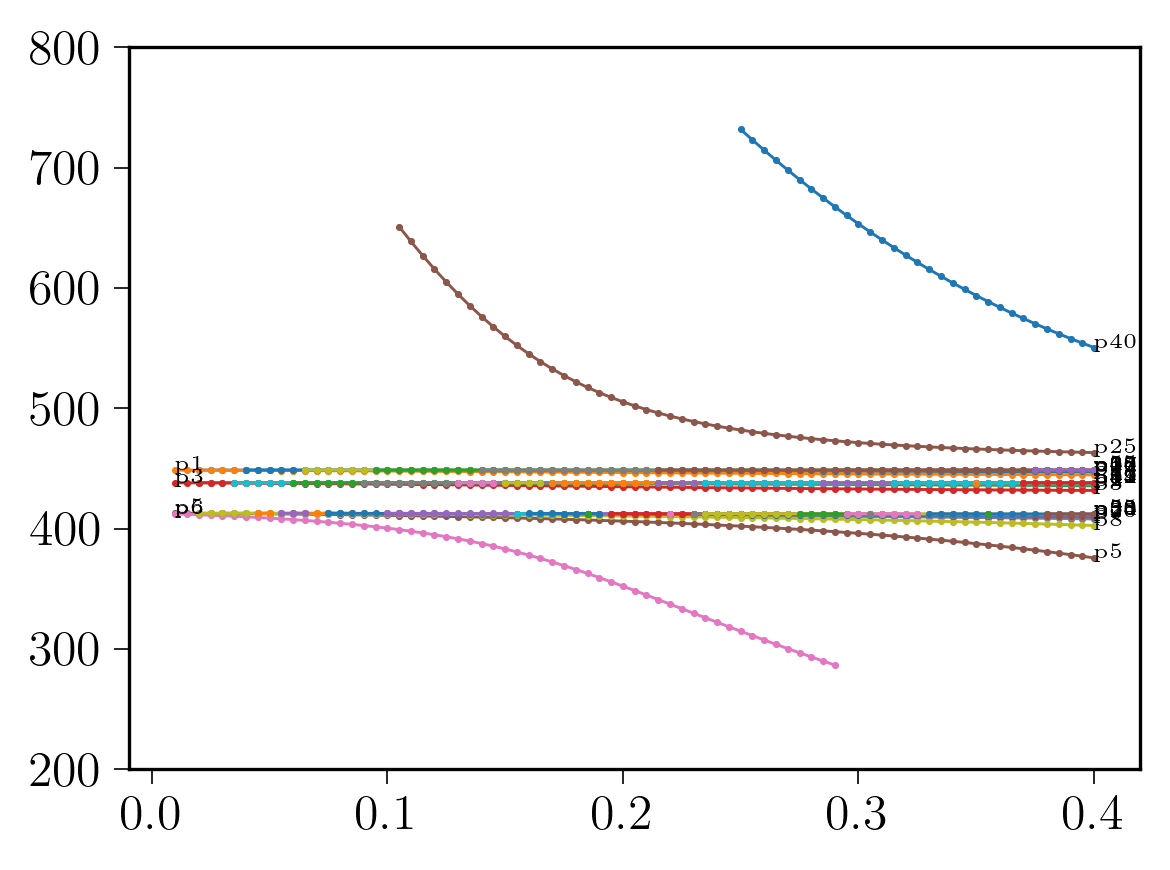

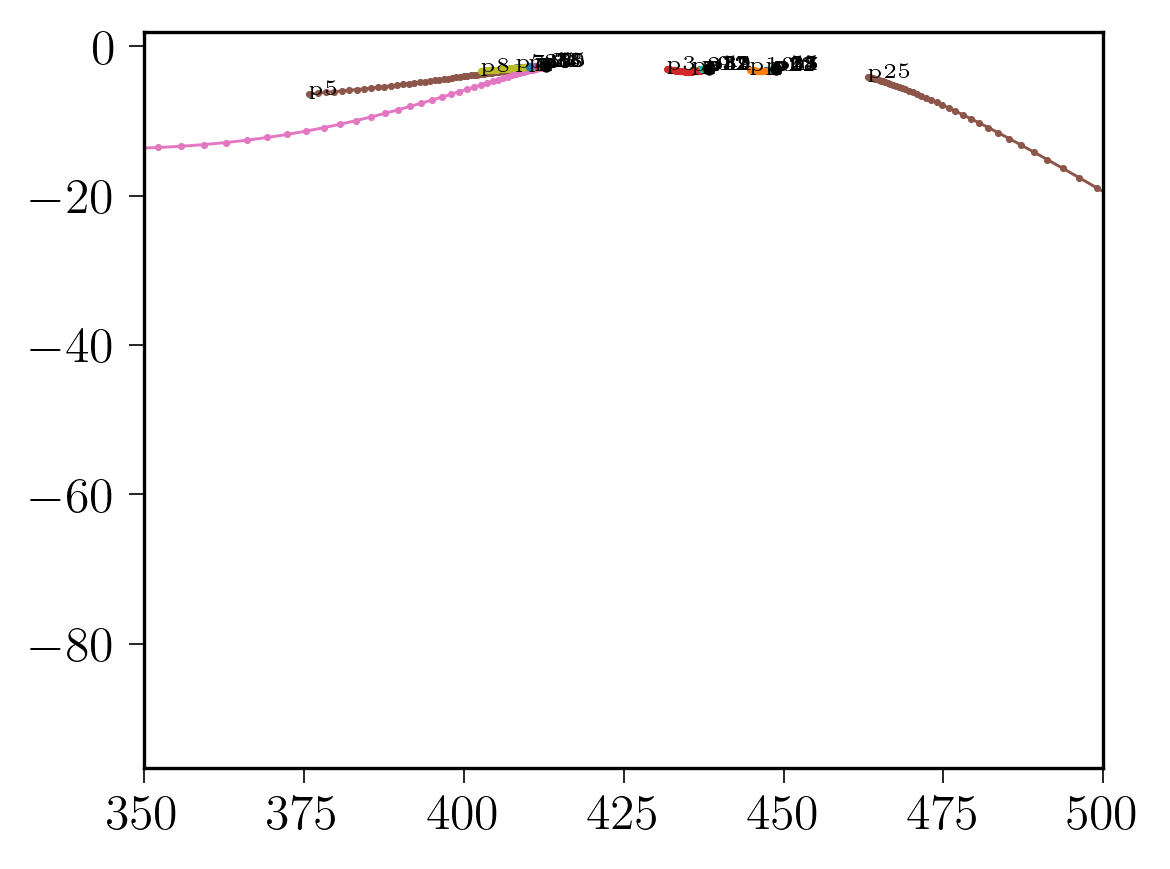

In [10]:
_ = plt.plot(thickness, poles_tracked_filtered.real*to_THz, ".-")
for i, ptf in enumerate(poles_tracked_filtered.T*to_THz):
    plt.annotate(f"p{i}", (thickness[0],ptf.real[0]), fontsize=5)
    plt.annotate(f"p{i}", (thickness[-1],ptf.real[-1]),fontsize=5)
plt.ylim(min(w_r), max(w_r))
plt.figure()

plt.plot(poles_tracked_filtered.real*to_THz, poles_tracked_filtered.imag*to_THz, ".-")
for i, ptf in enumerate(poles_tracked_filtered.T*to_THz):
    plt.annotate(f"p{i}", (ptf.real[0] , ptf.imag[0]), fontsize=5)
    plt.annotate(f"p{i}", (ptf.real[-1], ptf.imag[-1]),fontsize=5)

plt.scatter(material_poles.real/(2*np.pi), material_poles.imag/(2*np.pi), color="k", zorder=5)

plt.xlim(350, 500)
#plt.ylim((-8, -2))

/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


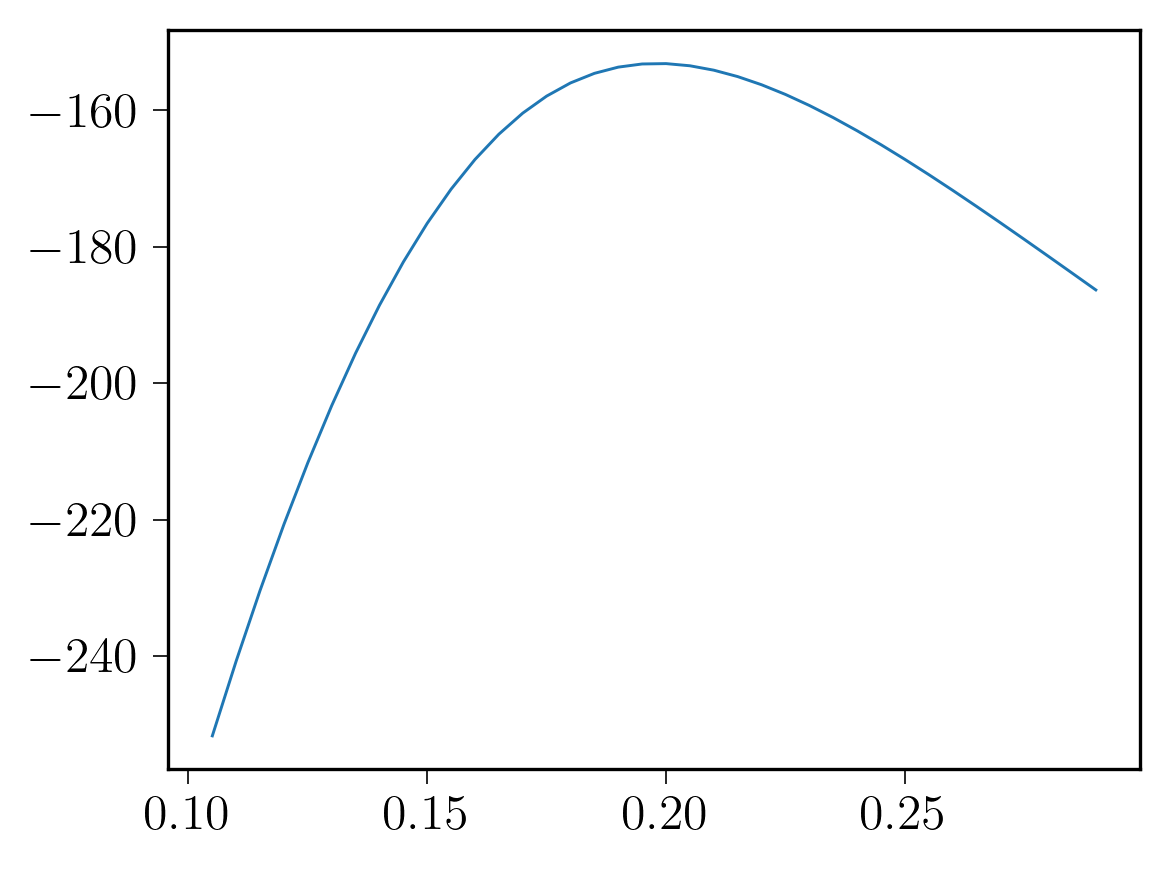

In [11]:
if npoles == 3:
  selection =[25, 1, 3, 6][::-1]
elif npoles==2:
  selection = [3,9,1] if osc==0.1 else [1,4,18]
else:
  selection = [1,120]
fundamental = poles_tracked_filtered[:, selection]
splitting = (fundamental[:, 0]-fundamental[:, -1])*to_THz
plt.plot(thickness, splitting)
rabi_idx = np.nanargmin(np.abs(splitting))
f_rabi = np.nanmin(np.abs(splitting))

/home/jd/phd/code/misc/agsurmof-cavity-rse/notebooks/inverse_eigenproblem.py:49: RuntimeWarning: invalid value encountered in divide
  fac = -1/(oms-evs)
/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


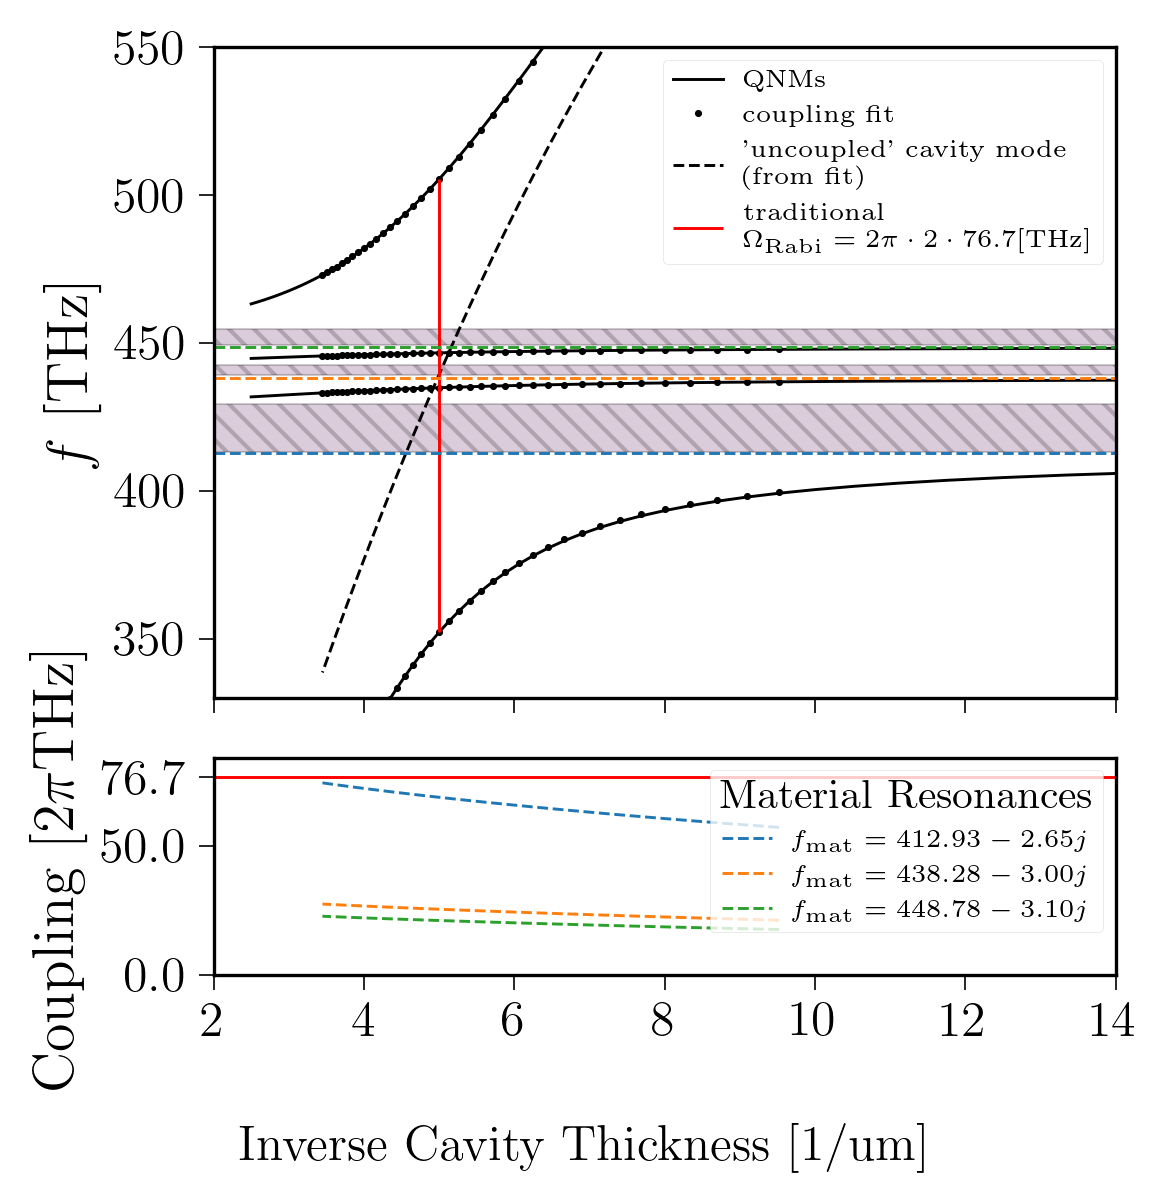

In [19]:
INV_L = True

param = 1/thickness if INV_L else thickness

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(4, 4), height_ratios=[3,1])
plt.sca(axs[0])

f_mode = fundamental.real*to_THz
plt.plot(param, f_mode, "k-")
plt.plot([],[], "k-", label="QNMs")

# for i, fund in enumerate(fundamental.real.T*to_THz):
#     idx = len(fund)//10*3
#     plt.annotate(f"mode {i}", (param[idx]+1.3, fund[idx]))


import inverse_eigenproblem
Cs=[]
om_os=[]
evs_fit = []
for i, t in enumerate(thickness):
    evs = fundamental[i]*to_THz*2*np.pi
    om_o, *couplings = inverse_eigenproblem.solve_inv_eig(
        evs, material_poles
    )
    Cs.append(couplings)
    om_os.append(om_o)
    evs_fit.append(inverse_eigenproblem.test_fwd_eig(om_o, material_poles, np.sqrt(couplings)))

plt.plot(param, np.array(evs_fit).real/(2*np.pi), "k.")
plt.plot([], [], "k.", label="coupling fit")
plt.plot(param, np.array(om_os)/(2*np.pi), "k--", label="'uncoupled' cavity mode\n(from fit)")
plt.vlines([param[rabi_idx]],*f_mode[rabi_idx, [0, -1]], color="r", label=f"traditional\n$\Omega_\mathrm{{Rabi}}=2\pi\cdot2\cdot{f_rabi.real/2:.1f}[\mathrm{{THz}}]$")
plt.ylim(330, 550)
plt.ylabel("$f$ [THz]")
plt.legend(fontsize=6)

for ls in lines.reshape(-1, 2):
    plt.fill_between((-2, 30), ls[0], ls[1], hatch="\\\\\\\\", color=(0.3,0,0.3,0.2), edgecolor=(0,0,0,0.2), lw=0.5)

for i,mat_pole in enumerate(material_poles/(2*np.pi)):
    plt.axhline(mat_pole, color=f"C{i}", linestyle="--")

plt.sca(axs[1])
# plt.gca().yaxis.tick_right()
# plt.gca().yaxis.set_label_position("right")
plt.ylabel("Coupling [$2\pi$THz]")
Cs = np.array(Cs)
cs = np.sqrt(np.real(Cs))/(2*np.pi)
for i,coupling in enumerate(cs.T):
    plt.plot(param, coupling, "--", label=f"$f_\mathrm{{mat}}={material_poles[i]/(2*np.pi):.2f}$")
plt.axhline(f_rabi.real/2, color="r")
plt.ylim(0, 1.1*f_rabi.real/2)
plt.yticks([0, 50, 76.7])
#plt.plot(param, np.sum(cs, axis=-1), label="sum")

plt.legend(fontsize=6, title="Material Resonances", loc="upper right")
if INV_L:
    fig.supxlabel("Inverse Cavity Thickness [1/um]")
    plt.xlim(2,14)
else:
    fig.supxlabel("Cavity Thickness [um]")

/tmp/ipykernel_199948/3249155556.py:7: RuntimeWarning: invalid value encountered in divide
  plt.plot(om_os/(2*np.pi), (np.pi*c0)/(om_os*1e12*thickness*1e-6), label="$c_0/(2fL)$")
/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jd/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


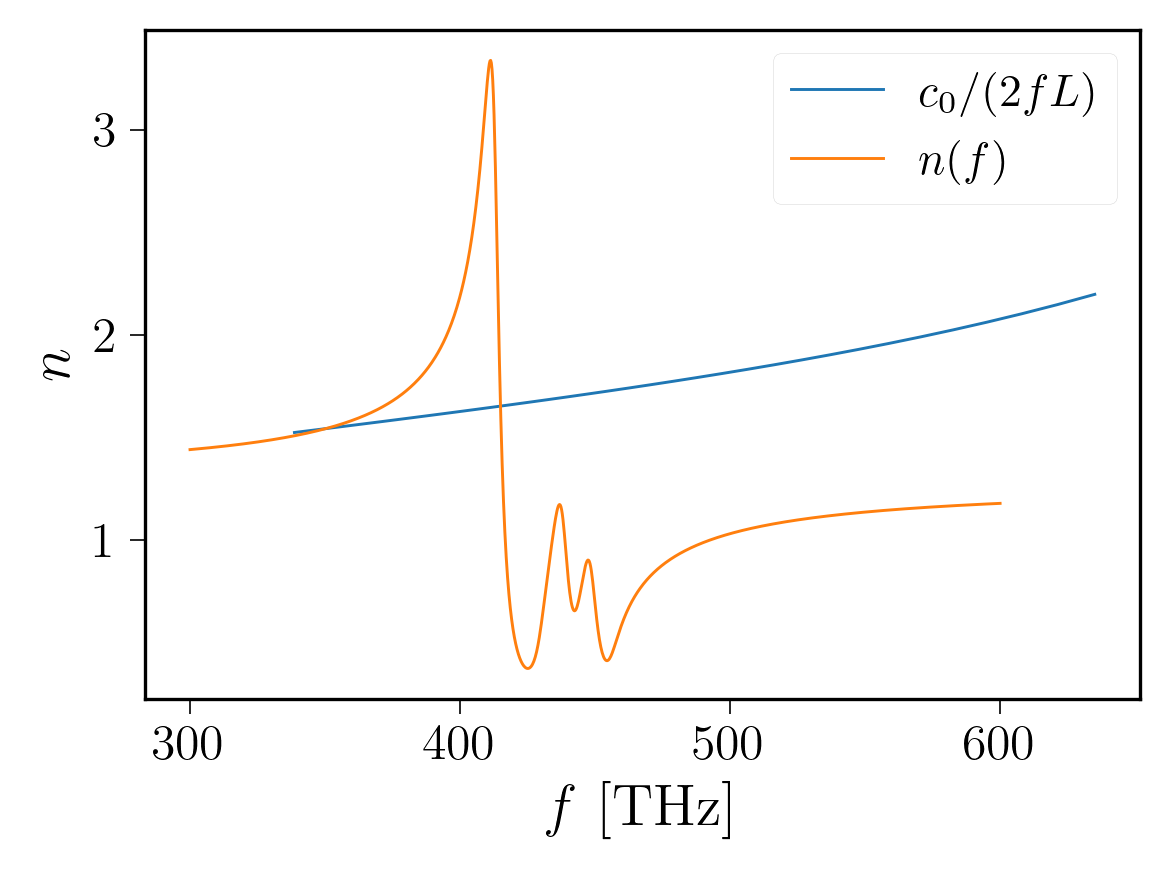

In [13]:
from scipy.constants import c as c0
om_os=np.array(om_os)

w_r = np.linspace(300, 600, 1200)

eps_r = eps_cav(w_r/to_THz, npoles, osc, damping)
plt.plot(om_os/(2*np.pi), (np.pi*c0)/(om_os*1e12*thickness*1e-6), label="$c_0/(2fL)$")
plt.plot(w_r, np.sqrt(eps_r), label="$n(f)$")
plt.xlabel("$f$ [THz]")
plt.ylabel("$n$")
plt.legend()

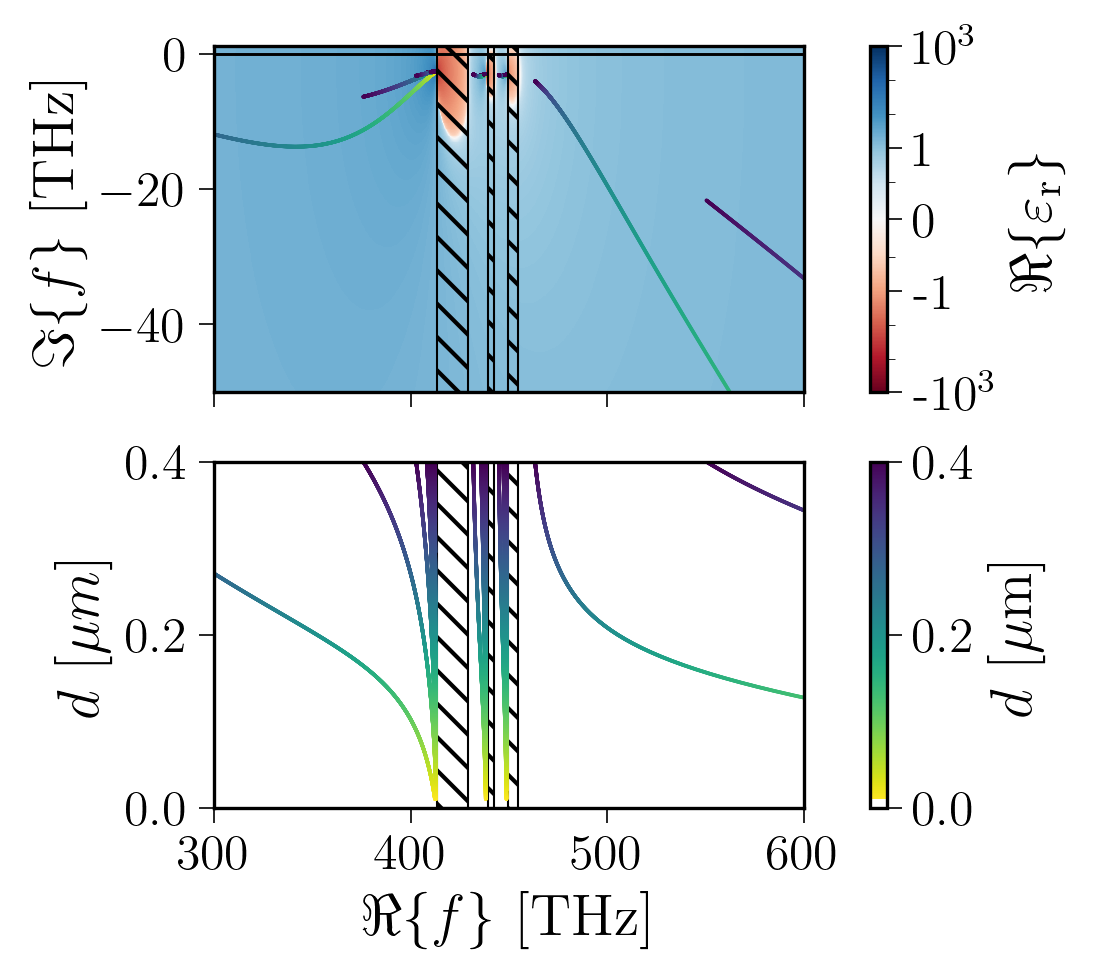

In [14]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(fig_width,80*mm), constrained_layout=True)
plt.sca(axs[0])
#w_r = np.linspace(380, 490, 1200)
w_r = np.linspace(300, 600, 1200)
w_i = np.linspace(-50, 1, 400)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, npoles, osc, damping)# eps_ag(W/to_THz) #

eps_r = eps_cav(w_r/to_THz, npoles, osc, damping)# eps_ag(w_r/to_THz) #
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                                            vmin=-1000.0, vmax=1000.0, base=10),
                    cmap="RdBu", rasterized=True)
cb = plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$", ticks=[-1e3, -1, 0, 1, 1e3])
cb.set_ticklabels(["-$10^3$", -1, 0, 1, "$10^3$"])

plt.ylim(plt.ylim())
plt.xlim(plt.xlim())

cmap = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))

interp_thick = np.linspace(min(thickness), max(thickness), 2000)
colors_interp = cmap(norm(interp_thick))
for pole in poles_tracked_filtered.T:
    real = np.interp(interp_thick, thickness, pole.real)
    imag = np.interp(interp_thick, thickness, pole.imag)
    plt.scatter(real*to_THz, imag*to_THz, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)

plt.ylabel("$\Im\{f\}$ [THz]")

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)
plt.axhline(0, color="k")

plt.sca(axs[1])
plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)
cb = plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="$d$ [$\mathrm{\mu m}$]")

for pole in poles_tracked_filtered.T:
    real = np.interp(interp_thick, thickness, pole.real)
    plt.scatter(real*to_THz, interp_thick, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)
    #plt.scatter(real*to_THz, 1/interp_thick, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)

# for line in lines:
#     plt.axvline(line)

plt.ylim((0, max(thickness)))
plt.ylabel("$d$ [$\mu m$]")

# plt.ylim((0, 8))
# plt.ylabel("$1/d$ [$\mu m^{-1}$]")
plt.xlim(min(w_r), max(w_r))
plt.xlabel("$\Re\{f\}$ [THz]")
plt.yticks([0, 0.2, 0.4])
cb.set_ticks(plt.yticks()[0])

plt.savefig(f"{name}_movement.pdf", dpi=600)